# Lab 03: Is There a Planet in Your Light Curve?

**ASTR 457, Fall 2026, posted Thu Sep 17, due Wed Sep 23 by Noon (fork → PR, as always)**

*Why this lab: transit fitting by maximum likelihood is how thousands of planets, including every temperate world around an M dwarf that David Charbonneau will talk about at the Sep 29 colloquium, were actually measured, and the gap between an error bar computed the lazy way and one computed honestly is exactly the gap between a claim that survives referees and one that doesn't.*

Every one of you has your own dataset: `data/<your netid>.csv`, with columns `t_days`
(time from the start of a ~27-day TESS-style observing sector, 30-minute cadence, with a
~1-day data gap in the middle), `flux_rel` (relative flux, normalized near 1), and
`sigma_flux` (the per-point **white-noise** uncertainty). Your star is a nearby M dwarf
with a candidate transiting super-Earth. The light curve contains: the transit train,
slow instrumental systematics (drifts over days), and, as you will discover, noise
that is not entirely captured by `sigma_flux`. I know the true mid-transit time $t_0$,
period $P$, depth $\delta$, and duration $T$ for your dataset. You don't, you can't look
them up, and your classmates' planets are different from yours.

**How this is graded.** As always: on whether your answers are *right* and your
uncertainties are *honest*. Your reported depth and period are compared to your truth in
units of your own reported uncertainty. Anti-sandbagging cap: your $\sigma_\delta$ may
not exceed 3× a reference uncertainty I compute for your dataset; defensive error bars
lose points just like overconfident ones.

**AI policy reminder.** Use whatever tools you like, including AI assistants, and
document it in Part 4. You may be selected to defend this lab in person (the practice
round was Sep 15; the real ones use the same format).

## The transit model (given)

Use this five-parameter periodic trapezoid, the small-planet limit of Mandel & Agol
(2002), the same model from Tuesday's lecture. The parameters are
$\theta = (t_0, P, \delta, T, F_0)$: mid-transit time of the first transit, period,
depth, total duration, and out-of-transit baseline flux. Ingress and egress each span
20% of the duration.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

def transit_model(t, t0, period, depth, duration, baseline, ingress_frac=0.2):
    """Periodic trapezoidal transit train."""
    ph = ((t - t0 + 0.5 * period) % period) - 0.5 * period
    half = duration / 2.
    ing = ingress_frac * duration
    f = np.ones_like(t)
    inside = np.abs(ph) < half
    full = np.abs(ph) < (half - ing)
    f[inside] = 1. - depth * np.clip((half - np.abs(ph[inside])) / ing, 0., 1.)
    f[full] = 1. - depth
    return baseline * f

NETID = 'ahuwer2'  # <-- set this
d = np.genfromtxt(f'data/{NETID}.csv', delimiter=',', names=True, skip_header=1)
t, flux, sigma = d['t_days'], d['flux_rel'], d['sigma_flux']
print(f'{len(t)} points spanning {t[-1]:.1f} days; stated sigma = {sigma[0]*1e3:.2f} ppt')

1263 points spanning 27.4 days; stated sigma = 1.20 ppt


## Part 1: Find the planet (20%)

1. Plot the raw light curve. Identify the slow systematic trend and the transits.
2. **Detrend** the light curve. Be deliberate: state your method (median filter, spline,
   polynomial per segment, your choice), your smoothing scale, and *why that scale
   can't eat your transits*. Plot raw, trend, and detrended flux.
3. From the detrended curve, read off by eye: approximate $t_0$, $P$, depth, duration:
   your initial guesses for Part 2.
4. Compare the out-of-transit scatter of your detrended flux to the stated `sigma_flux`.
   Are they consistent? Say what you conclude (a sentence is fine, and you'll need this
   observation in Parts 2 and 3).

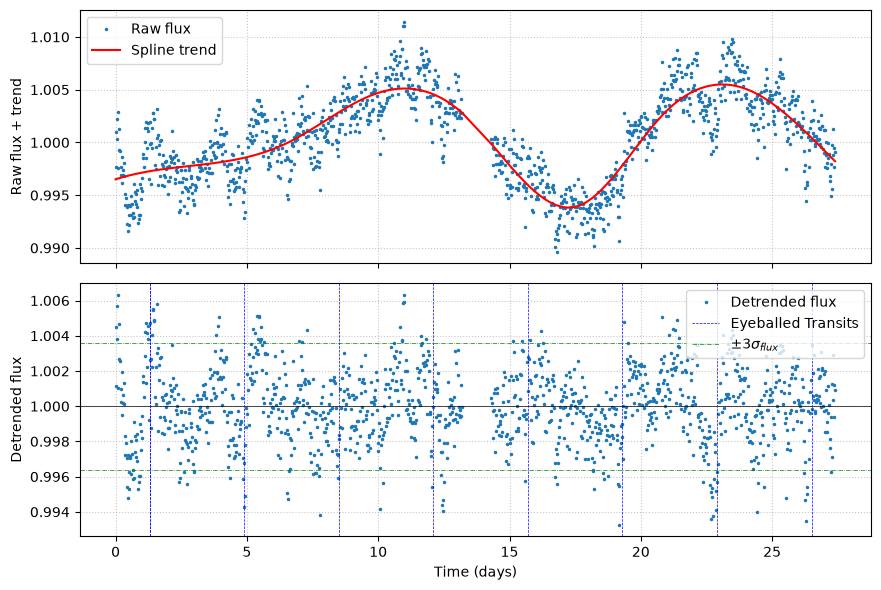

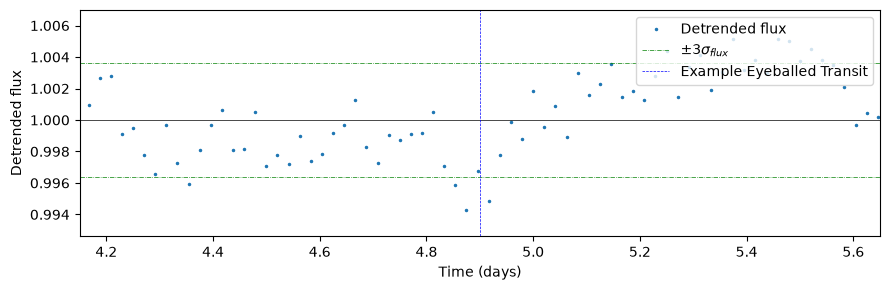

out-of-transit scatter (MAD): 0.00140 vs stated sigma_flux: 0.00120


In [2]:
# Part 1: your work here
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import UnivariateSpline
from scipy.stats import median_abs_deviation as MAD

# load file
datafile = f'./data/{NETID}.csv'
data = pd.read_csv(datafile,skiprows=1)
# print(data)
ts = data['t_days'].values
fluxes = data['flux_rel'].values
sigmas = data['sigma_flux'].values

N = len(ts)
#dt= ts[1] - ts[0]
#print(f"dt = {dt*24:.5f} hr") 

spl = UnivariateSpline(ts, fluxes, w=1/sigmas, s=3.25*N)
trend = spl(ts)
detrended = fluxes / trend
# trend = pd.Series(fluxes).rolling(window=96, center=True, min_periods=1).median()
# detrended = fluxes / trend

guess_t0 = 1.3
guess_P = 3.6#/2

fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True)
axes[0].plot(ts, fluxes, 'o', ms=1.5, label='Raw flux')
axes[0].plot(ts, trend, 'r-', lw=1.5, label='Spline trend')
axes[0].set_ylabel('Raw flux + trend')
axes[0].legend()

axes[1].plot(ts, detrended, 'o', ms=1.5, label='Detrended flux')
axes[1].axhline(1.0, color='k', lw=0.5)
axes[1].axhline(1.0 + 3*np.median(sigmas), color='g', lw=0.5, linestyle='-.')
axes[1].axvline(guess_t0, color='b', lw=0.5, linestyle='--', label='Eyeballed Transits')
i=0
while guess_t0+guess_P*i<max(ts):
      axes[1].axvline(guess_t0+guess_P*i, color='b', lw=0.5, linestyle='--')
      i+=1
axes[1].axhline(1.0 - 3*np.median(sigmas), color='g', lw=0.5, linestyle='-.', label='$\\pm 3\\sigma_{flux}$')
axes[1].set_ylabel('Detrended flux')
axes[1].legend(loc='upper right')

axes[0].grid(True, alpha=0.7, linestyle=':')
axes[1].grid(True, alpha=0.7, linestyle=':')
plt.xlabel('Time (days)')
plt.tight_layout()
plt.show()

plt.figure(figsize=(9,3))
plt.plot(ts, detrended, 'o', ms=1.5, label='Detrended flux')
plt.axhline(1.0, color='k', lw=0.5)
plt.axhline(1.0 + 3*np.median(sigmas), color='g', lw=0.5, linestyle='-.', label='$\\pm 3\\sigma_{flux}$')
plt.axhline(1.0 - 3*np.median(sigmas), color='g', lw=0.5, linestyle='-.')
plt.axvline(guess_t0+guess_P*1, color='b', lw=0.5, linestyle='--', label='Example Eyeballed Transit')
plt.ylabel('Detrended flux')
plt.xlim([guess_t0+guess_P*1 - 0.75, guess_t0+guess_P*1 + 0.75])
plt.legend(loc='upper right')
plt.grid(True, alpha=0., linestyle=':')
plt.xlabel('Time (days)')
plt.tight_layout()
plt.show()

# use MAD for scatter
mad = MAD(detrended)
print(f'out-of-transit scatter (MAD): {mad:.5f} vs stated sigma_flux: {sigmas[0]:.5f}')

**ANSWERS (initial guesses + scatter check):**

I used the spline method here, which shouldn't eat my transits since I've set the smoothing such that it only reacts to general trends over the span of more than a day. Considering I expect the transits to be a few hours long, larger windows are better (up to a point) for safety so that we don't accidentally eliminate some of the transit data by using too small of a window in the case of medians or too low of smoothing in the case of splines as I used here. For context, while splines and medians won't really look the same, a window of 96-152 (48 to 76 hours) looks relatively close to my current choice of spline.

$t_0\approx1.3$ days,
$P\approx3.6$ days,
$\delta\approx0.004$, and
$T\approx0.2$ days.
Trying to visually detect the transits with all this noise was really difficult, but from the plot we can see really significant dips around $t\sim5,12.5,18,23,27$. The best choices of $t_0,P$ I found that fit all those points were $\sim1.2-1.3$ for $t_0$ and $\sim3.6$ or $3.6/2=1.8$ for $P$. I would've selected a later $t_0$ if not for the fact that physically it doesn't make sense for a transit to get skipped, and the data is very noisy at the start, so I'm guessing that the spike at that point is offsetting the transit somehow as that choice of first transit time makes most of the other dips line up. It's very possible the actual period is twice what I decided on, but based on the largest peaks I think it's slightly more likely to be the period I chose.

Out of transit scatter was $0.00140$ vs $\sigma_{flux}=0.00120$. Since the scatter is higher than $\sigma_{flux}$, we can deduce that there's probably some other component to the noise which is correlated or otherwise not fully described by $\sigma_{flux}$.

## Part 2: The measurement you'd publish (40%)

1. Write the Gaussian log-likelihood for the transit model and maximize it
   (`scipy.optimize.minimize`; Nelder-Mead first, as in lecture). Fit all five
   parameters. Plot the phase-folded data with your best-fit model, and the residuals.
2. Estimate uncertainties **two ways**:
   - from the curvature of the log-likelihood at the maximum (the inverse Hessian,
     lecture method), and
   - by **bootstrap**, and think about *what* you resample: if you resample individual
     points, what are you assuming about the noise? A block bootstrap (resample
     contiguous chunks of residuals, e.g. 1-day blocks) makes a different assumption.
     Do both point-wise and block versions and compare.
3. The three uncertainty estimates for the depth will not all agree. Explain the pattern
   using your Part 1 scatter observation. Which noise property do the Hessian and the
   point-wise bootstrap both assume that your residuals violate? Demonstrate that
   violation with a plot or a number (hint: bin your residuals in ~5-hour bins and
   compare the binned scatter to what independent noise predicts).
4. **Commit to final answers**: $\delta \pm \sigma_\delta$, $P \pm \sigma_P$,
   $t_0 \pm \sigma_{t_0}$, and justify which uncertainty estimate you adopted.

Best-fit parameters:
  t0       = 1.34090 d
  P        = 3.56250 d
  depth    = 3.247 ppt
  duration = 0.22347 d
  F0       = 1.00016
  converged: True, chi2_min = 3943.48


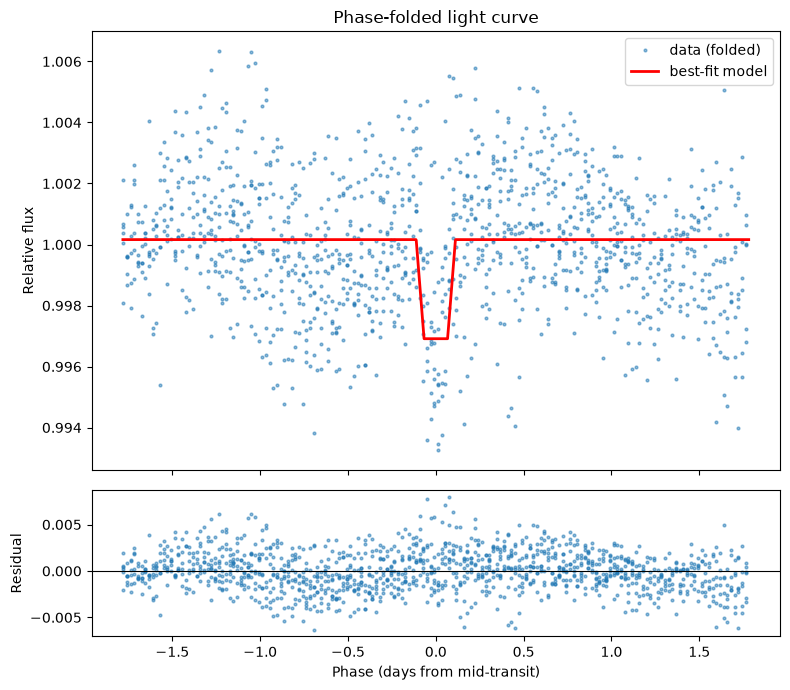


Hessian (curvature) uncertainties:
  t0: 1.340903 +/- 0.000783
  period: 3.562500 +/- 0.000541
  depth: 0.003247 +/- 0.000156
  duration: 0.223472 +/- 0.000446
  F0: 1.000161 +/- 0.000035

Point-wise bootstrap uncertainties:
  t0: 0.020954
  period: 0.004742
  depth: 0.000490
  duration: 0.025319
  F0: 0.000061

Block bootstrap uncertainties:
  t0: 0.014501
  period: 0.003399
  depth: 0.000539
  duration: 0.021267
  F0: 0.000201

5-hr bins: observed std = 1.5691 ppt, white-noise-predicted std = 0.3795 ppt, ratio = 4.14


In [3]:
# Part 2: your work here

# --- 1. Log-likelihood (Gaussian, per-point sigma) ---
def neg_log_likelihood(theta, t, flux, sig):
    t0, period, depth, duration, F0 = theta
    if period <= 0 or duration <= 0 or duration >= period:
        return np.inf  # keep optimizer in a physical region
    model = transit_model(t, t0, period, depth, duration, F0)
    resid = flux - model
    chi2 = np.sum((resid / sig) ** 2)
    return 0.5 * chi2   # this is -lnL up to a constant

# --- 2. Initial guesses and solving ---
t0_guess       = guess_t0
period_guess   = guess_P
depth_guess    = 0.004
duration_guess = 0.2
F0_guess       = 1.0

theta0 = [t0_guess, period_guess, depth_guess, duration_guess, F0_guess]

result = minimize(neg_log_likelihood, theta0, args=(ts, detrended, sigmas),method='Nelder-Mead')

theta_hat = result.x
t0_hat, P_hat, depth_hat, dur_hat, F0_hat = theta_hat
print("Best-fit parameters:")
print(f"  t0       = {t0_hat:.5f} d")
print(f"  P        = {P_hat:.5f} d")
print(f"  depth    = {depth_hat*1e3:.3f} ppt")
print(f"  duration = {dur_hat:.5f} d")
print(f"  F0       = {F0_hat:.5f}")
print(f"  converged: {result.success}, chi2_min = {2*result.fun:.2f}")

# --- 3. Phase-folded plots with the best-fit model and residuals ---
phase = ((ts - t0_hat + 0.5 * P_hat) % P_hat) - 0.5 * P_hat
order = np.argsort(phase)

phase_dense = np.linspace(-0.5 * P_hat, 0.5 * P_hat, 2000)
t_dense = phase_dense + t0_hat
model_dense = transit_model(t_dense, t0_hat, P_hat, depth_hat, dur_hat, F0_hat)

model_at_data = transit_model(ts, t0_hat, P_hat, depth_hat, dur_hat, F0_hat)
resid = detrended - model_at_data

fig, axes = plt.subplots(2, 1, figsize=(8, 7), sharex=True,
                          gridspec_kw={'height_ratios': [3, 1]})
axes[0].plot(phase[order], detrended[order], 'o', ms=2, alpha=0.5, label='data (folded)')
axes[0].plot(phase_dense, model_dense, 'r-', lw=2, label='best-fit model')
axes[0].set_ylabel('Relative flux')
axes[0].legend()
axes[0].set_title('Phase-folded light curve')


axes[1].plot(phase[order], resid[order], 'o', ms=2, alpha=0.5)
axes[1].axhline(0, color='k', lw=0.8)
axes[1].set_xlabel('Phase (days from mid-transit)')
axes[1].set_ylabel('Residual')
plt.tight_layout()
plt.show()


# --- 4a. Uncertainty via curvature (Hessian of neg_log_likelihood)
theta_star = theta_hat
n = len(theta_star)
h = 1e-4 * np.maximum(np.abs(theta_star), 1e-3)   # scaled step per parameter
hess = np.zeros((n, n))
for i in range(n):
    for j in range(n):
        ei, ej = np.zeros(n), np.zeros(n)
        ei[i] = h[i]; ej[j] = h[j]
        hess[i, j] = (neg_log_likelihood(theta_star + ei + ej, ts, detrended, sigmas)
                      - neg_log_likelihood(theta_star + ei - ej, ts, detrended, sigmas)
                      - neg_log_likelihood(theta_star - ei + ej, ts, detrended, sigmas)
                      + neg_log_likelihood(theta_star - ei - ej, ts, detrended, sigmas)) / (4 * h[i] * h[j])

cov_hessian = np.linalg.inv(hess)
sigma_hessian = np.sqrt(np.diag(cov_hessian))

param_names = ['t0', 'period', 'depth', 'duration', 'F0']
print("\nHessian (curvature) uncertainties:")
for name, val, err in zip(param_names, theta_hat, sigma_hessian):
    print(f"  {name}: {val:.6f} +/- {err:.6f}")

# --- 4b. Uncertainty via bootstrap: point-wise
np.random.seed(1)
n_boot = 300
boot_params_pointwise = np.zeros((n_boot, 5))

for b in range(n_boot):
    idx = np.random.choice(N, N, replace=True)
    tb, fb, sb = ts[idx], detrended[idx], sigmas[idx]
    res_b = minimize(neg_log_likelihood, theta_hat, args=(tb, fb, sb),
                      method='Nelder-Mead')
    boot_params_pointwise[b] = res_b.x

sigma_boot_pointwise = boot_params_pointwise.std(axis=0)
print("\nPoint-wise bootstrap uncertainties:")
for name, err in zip(param_names, sigma_boot_pointwise):
    print(f"  {name}: {err:.6f}")

# --- 4c. Uncertainty via bootstrap: block bootstrap
np.random.seed(2)
block_size_days = 1.0
dt = np.median(np.diff(t))
block_size_pts = max(1, int(round(block_size_days / dt)))

n_blocks = N // block_size_pts
blocks = [np.arange(i*block_size_pts, min((i+1)*block_size_pts, N))
          for i in range(n_blocks)]

resid_at_data = detrended - model_at_data

boot_params_block = np.zeros((n_boot, 5))
for b in range(n_boot):
    chosen_blocks = [blocks[i] for i in
                      np.random.choice(len(blocks), len(blocks), replace=True)]
    resampled_resid = np.concatenate([resid_at_data[blk] for blk in chosen_blocks])[:N]
    fb = model_at_data[:len(resampled_resid)] + resampled_resid
    tb = t[:len(resampled_resid)]
    sb = sigmas[:len(resampled_resid)]
    res_b = minimize(neg_log_likelihood, theta_hat, args=(tb, fb, sb),
                      method='Nelder-Mead')
    boot_params_block[b] = res_b.x

sigma_boot_block = boot_params_block.std(axis=0)
print("\nBlock bootstrap uncertainties:")
for name, err in zip(param_names, sigma_boot_block):
    print(f"  {name}: {err:.6f}")

# --- 5. Binning
bin_hours = 5.0
bin_days = bin_hours / 24.0
n_per_bin = max(1, int(round(bin_days / dt)))

n_full_bins = N // n_per_bin
binned_means = np.array([resid_at_data[i*n_per_bin:(i+1)*n_per_bin].mean()
                          for i in range(n_full_bins)])
observed_bin_std = binned_means.std()
expected_bin_std = np.median(sigmas) / np.sqrt(n_per_bin)

print(f"\n5-hr bins: observed std = {observed_bin_std*1e3:.4f} ppt, "
      f"white-noise-predicted std = {expected_bin_std*1e3:.4f} ppt, "
      f"ratio = {observed_bin_std/expected_bin_std:.2f}")

**FINAL ANSWER:** $\delta = $ 3.247 $\pm$ 0.539 ppt, $P = $ 3.562500 $\pm$ 0.003399 d, $t_0 = $ 1.340903 $\pm$ 0.000783 d

**Which uncertainty and why (a short paragraph):**

I've chosen to stick with the block bootstrapped uncertainty values, as the other two cases (Hessian, point bootstrapping) have the underlying assumption that the data is not correlated in any way, which doesn't seem to be true given that the residuals plot has a somewhat sinusoidal shape, which is particularly near the edges since we can see some curvature. This is backed up by the fact that our binned deviations are over four times larger than the expected case for white noise, indicating that there's correlation in our data. Since the block bootstrapping case does not make this assumption, it should be more accurate, so I've chosen it here.

## Part 3: The referee report (30%)

The file `ai_solution.ipynb` in this directory is a complete, tidy, confident analysis
of this exact problem, produced by an AI assistant. It runs top to bottom without
errors, the phase-folded plot looks professional, and the prose is fluent. It is also
wrong, in at least **three** distinct, substantive ways (cosmetic nitpicks don't
count).

Write a referee report:

1. **Identify** at least three substantive statistical errors.
2. **Demonstrate** each one quantitatively on *your* dataset. Show, with a number or a
   plot, what the error does to the inference. "This is bad practice" is not a
   demonstration.
3. **State** what the correct treatment is (you already built it in Part 2).

You've done this once before, on Lab 01. Notice how much faster you are at it now.
That speed is the skill this course is building.

**REFEREE REPORT:**

*Flaw 1:* The AI chose to calculate its window, which after printing the values on my end, I can see it landed on window=12. This corresponds to a 6-hour window, which is quite small and thus artifically cuts the flux changes caused by the transit. If I'm right (or close to right) about the transit duration, then 0.223472 days is about 5.4 hours, so the median window is only slightly greater than the whole transit duration. This short window means the trend is relatively mobile, and the detrend process is able to remove or dampen relatively quick swings in flux compared to a longer window. This causes most of their detrended data to be spread relatively more evenly around 1 than it would otherwise, which is an issue particularly for the transit data points. And an inaccurate detrended dataset will just cascade errors later on.

*Flaw 2:* When first computing the error/noise in the detrended data, it used the basic standard deviation which is a worse estimator of scatter here than something like MAD. With that it'll be affected significantly by the transit data points which lie signficantly lower than most of the data.

*Flaw 3:* When later computing the error of the fit, it only computed the 1D curvature instead of the full curvature or equivalently, finding the Hessian and using that. And that's just for a basic measure of error, which as I said in part 2 I expect to be less accurate than block bootstrapping.

--- DEMONSTRATION 1 ---


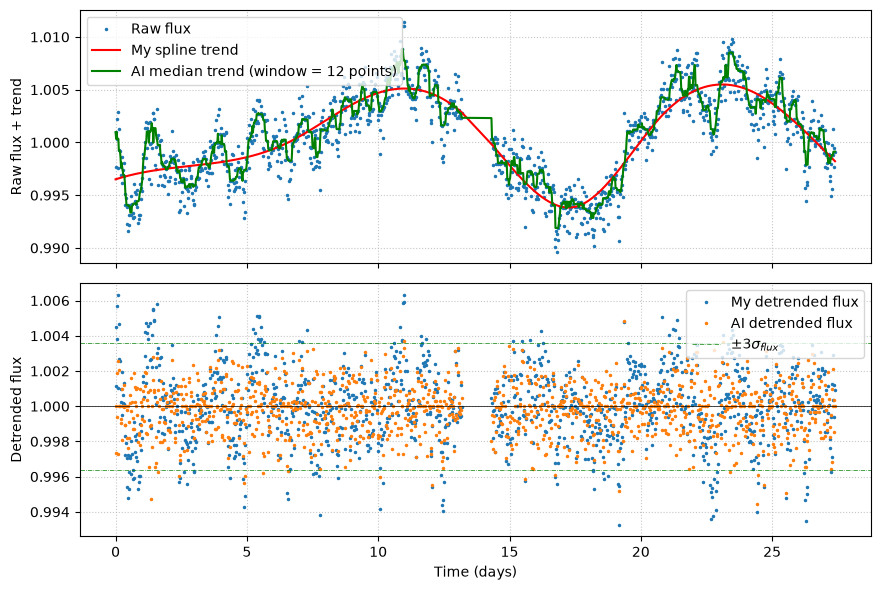

--- DEMONSTRATION 2 ---
Out-of-transit scatter found with std: 0.00216
Out-of-transit scatter found with MAD: 0.00140
Ratio (std/MAD): 1.53963
Standard deviation overestimates scatter as it includes the transit outliers without being robust against such data.

--- DEMONSTRATION 3 ---
AI depth error (1D curvature) = +/- 0.177 ppt
My depth error (Block bootstrap)= +/- 0.539 ppt
Error ratio (AI/Mine): 0.328


In [4]:
from scipy.ndimage import median_filter

# Flaw 1 Demonstration:
print('--- DEMONSTRATION 1 ---')
my_spl = UnivariateSpline(ts, fluxes, w=1/sigmas, s=3.25*N)
my_trend = my_spl(ts)
my_detrended = fluxes / my_trend

cadence = np.median(np.diff(t))
window = max(3, int(round((6.0 / 24.) / cadence)))
ai_trend = median_filter(flux, size=window)
ai_detrended = flux - ai_trend + 1.0

fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True)
axes[0].plot(ts, fluxes, 'o', ms=1.5, label='Raw flux')
axes[0].plot(ts, my_trend, 'r-', lw=1.5, label='My spline trend')
axes[0].plot(ts, ai_trend, 'g-', lw=1.5, label=f'AI median trend (window = {window} points)')
axes[0].set_ylabel('Raw flux + trend')
axes[0].legend()

axes[1].plot(ts, my_detrended, 'o', ms=1.5, label='My detrended flux')
axes[1].plot(ts, ai_detrended, 'o', ms=1.5, label='AI detrended flux')
axes[1].axhline(1.0, color='k', lw=0.5)
axes[1].axhline(1.0 + 3*np.median(sigmas), color='g', lw=0.5, linestyle='-.')
axes[1].axhline(1.0 - 3*np.median(sigmas), color='g', lw=0.5, linestyle='-.', label='$\\pm 3\\sigma_{flux}$')
axes[1].set_ylabel('Detrended flux')
axes[1].legend(loc='upper right')

axes[0].grid(True, alpha=0.7, linestyle=':')
axes[1].grid(True, alpha=0.7, linestyle=':')
plt.xlabel('Time (days)')
plt.tight_layout()
plt.show()

# Flaw 2 Demonstration:
scatter_std = np.std(detrended)
print('--- DEMONSTRATION 2 ---')
print(f'Out-of-transit scatter found with std: {scatter_std:.5f}')
print(f'Out-of-transit scatter found with MAD: {mad:.5f}')
print(f'Ratio (std/MAD): {scatter_std/mad:.5f}')
print('Standard deviation overestimates scatter as it includes the transit outliers without being robust against such data.\n')

# Flaw 3 Demonstration:
print('--- DEMONSTRATION 3 ---')
# AI method:
t0_fit, P_fit, depth_fit, dur_fit, base_fit = theta_hat
h = depth_fit * 1e-3
def nll_d(dd):
    th = theta_hat.copy(); th[2] = dd
    return neg_log_likelihood(th, t, detrended, mad)
curv = (nll_d(depth_fit + h) - 2 * nll_d(depth_fit) + nll_d(depth_fit - h)) / h**2
sigma_depth = 1.0 / np.sqrt(curv)

#actual values
real_sigma_depth = sigma_boot_block[2]
print(f'AI depth error (1D curvature) = +/- {sigma_depth*1e3:.3f} ppt')
print(f'My depth error (Block bootstrap)= +/- {real_sigma_depth*1e3:.3f} ppt')
print(f'Error ratio (AI/Mine): {sigma_depth/real_sigma_depth:.3f}')

## Part 4: AI-use appendix & verification plan (10%)

1. **AI use**: which tools did you use, for what, what did they get wrong, and how did
   you catch it? Honesty is graded; "I didn't use any" is fine if true.
2. **Verification plan**: list the checks you ran before deciding to trust your Part 2
   numbers. For each check: what would failure have looked like? (One check you should
   seriously consider: simulate a light curve with parameters you chose, run your whole
   pipeline on it, and see whether you recover what you put in.)

**AI-USE APPENDIX:**

For part 1: Used claude to generate the plots and google's ai to find a spline technique. I dialed in all of the values (particularly s, while also testing median with different windows) to get what I thought was a reasonable detrend, and the eyeballing of transits was also my work. The only minor issue was it defaulted to the standard deviation when finding the scatter, which I needed to replace with the median absolute deviation to be more representative of the scatter excluding the transits. Otherwise, basically all the issues came down to trying to choose and interpret a reasonable value of s and the initial guesses.

For part 2: Claude was used to generate most of the code using descriptions of how I'd like the aspects done, like for example the specific method to compute the Hessian (based on the example in lecture 7, fitting the cepheids). This time it did make a few mistakes which I had to correct.

For part 3: The whole report was made without AI, including the code (most was copy+paste with small tweaks).

For the verification plan: The plan was my own but as before I had help from Claude in writing it. Most parts were correct as I simply gave it the code I had been using and told it to just quickly implement a simulation with values that I chose by hand and recycle my old code just with new variables. The only issue was on my part, as I forgot to explicitly specify I wanted to use the block bootstrap that I actually decided on using, and so Claude simply chose to use the Hessian which inflated the actual sigma values used to confirm things at the end. Note that the print statements at the end used to analyze/justify the plots are of my making and are *not* Claude or another model analyzing the data without having actually looked at it, as many AIs seem to do.

**VERIFICATION PLAN:**

The main plan is simply to do as recommended and simulate and refit with the exact same choice and specifics of method (e.g. things like using the same $s$ value for the splines) on significantly different base transit truths. Since I am still not 100% on my choice of initial parameters, the verified plot below should help me figure out whether this method works on a general known case. If I see values where the truth is within 1 sigma (and the errors are not obviously overblown, e.g. something like $a=0.0046$ and $\sigma_a=0.0091$), then I can be reasonably confident my method is correct. Failure cases would mostly just be the opposite: reasonably small errors and values of the fit parameters which closely match the simulated truths.

Injected: t0=1.44, P=5.73, depth=2.40 ppt, duration=0.35, F0=1.0
simulated scatter: 1.39 ppt vs stated sigma: 1.20 ppt

Recovered (chi2_min=3938.4, converged=True):
  t0      : fit=1.435485 +/- 0.122592   truth=1.440000   offset=-0.04 sigma   offset using hessian=-1.98 sigma
  period  : fit=5.732369 +/- 0.090033   truth=5.730000   offset=+0.03 sigma   offset using hessian=1.14 sigma
  depth   : fit=0.002061 +/- 0.000708   truth=0.002400   offset=-0.48 sigma   offset using hessian=-2.15 sigma
  duration: fit=0.348519 +/- 0.287009   truth=0.350000   offset=-0.01 sigma   offset using hessian=-0.96 sigma
  F0      : fit=1.000108 +/- 0.000330   truth=1.000000   offset=+0.33 sigma   offset using hessian=3.12 sigma


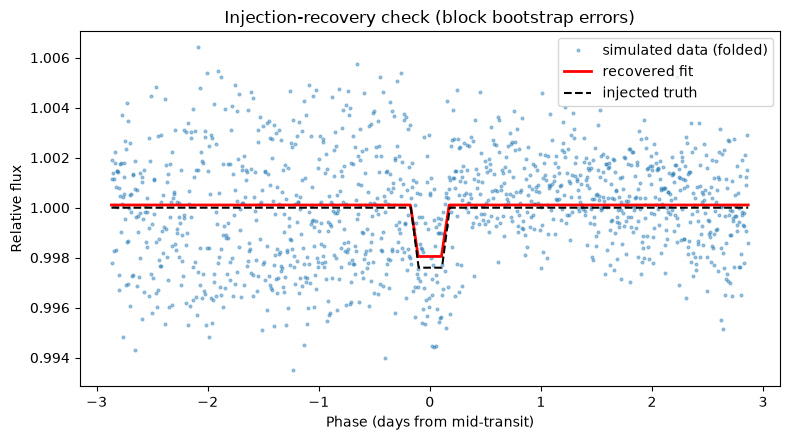

My analysis:

The exact process I used on the csv data, now applied to the simulation, yielded
a great result in all values. The fit was quite good with all variables converging
withing 0.5 sigma, using the block bootstrap method as before. For reference, I've
also provided the offsets in sigma from the truth using the Hessian error values.
The lowest (magnitude) here is 0.96 sigma, with several others around 2 or 3, which 
shows that the block bootstrap case is more accurate to what we should expect. Also, 
you can simply look at the plot visually and see that it's quite accurate. Note that 
the values with the most error here are t0 and duration, which makes sense as the
transit is short in duration and we only have data every 30 minutes, so the large
base scatter within that short frame makes slight offsets for those fit values likely.
The depth fit is the most noticeable issue here, but given the signal to noise ratio
is still quite low and our errors are larger to make up for that

In [5]:
# ============================================================
# Injection-recovery test
# Simulate a light curve with known parameters, run the full
# Detrend + fir pipeline on it, and check whether we
# recover what we put in.
# ============================================================

np.random.seed(3)  # reproducible

# --- injected truth ---
t0_true, P_true, depth_true, dur_true = 1.44, 5.73, 0.0024, 0.35
F0_true = 1.0

# realistic systematic trend: a slow multi-day wobble similar in
# character to the real data's spline trend
trend_true = 1.0 + 0.003*np.sin(2*np.pi*ts/13.5) + 0.002*np.cos(2*np.pi*ts/9.0)

transit_true = transit_model(ts, t0_true, P_true, depth_true, dur_true, 1.0)

# --- noise: white noise at the stated sigma_flux, PLUS a correlated
# (red) component, mimicking the ~1.8-2x excess scatter you found in
# your real detrended residuals ---
white_noise = np.random.normal(0, sigmas)
raw_red = np.random.normal(0, sigmas.mean(), size=len(ts))
kernel = np.ones(5) / 5          # ~2.5 hr smoothing window
red_noise = np.convolve(raw_red, kernel, mode='same') * 1.3

flux_sim = trend_true * transit_true + white_noise + red_noise

print(f"Injected: t0={t0_true}, P={P_true}, depth={depth_true*1e3:.2f} ppt, "
      f"duration={dur_true}, F0={F0_true}")
print(f"simulated scatter: {(white_noise+red_noise).std()*1e3:.2f} ppt "
      f"vs stated sigma: {sigmas.mean()*1e3:.2f} ppt")

# --- Part 1 step: detrend with the same spline recipe you used on real data ---
spl_sim = UnivariateSpline(ts, flux_sim, w=1/sigmas, k=3, s=3.25*len(ts))
trend_fit_sim = spl_sim(ts)
detrended_sim = flux_sim / trend_fit_sim

# --- Part 2 step: fit with multi-start over period (deliberately
# WRONG initial guess, to test the pipeline's robustness) ---
t0_guess0, P_guess0 = 1.3, 5.5
depth_guess0, dur_guess0, F0_guess0 = 0.003, 0.3, 1.0

period_grid = np.linspace(P_guess0 - 0.5, P_guess0 + 0.5, 41)
best_result, best_chi2 = None, np.inf
for P_try in period_grid:
    theta0 = [t0_guess0, P_try, depth_guess0, dur_guess0, F0_guess0]
    res = minimize(neg_log_likelihood, theta0, args=(ts, detrended_sim, sigmas),
                    method='Nelder-Mead')
    chi2 = 2 * res.fun
    if res.success and chi2 < best_chi2:
        best_chi2, best_result = chi2, res

theta_hat_sim = best_result.x
t0_hat_sim, P_hat_sim, depth_hat_sim, dur_hat_sim, F0_hat_sim = theta_hat_sim
model_at_data_sim = transit_model(ts, t0_hat_sim, P_hat_sim, depth_hat_sim,
                                   dur_hat_sim, F0_hat_sim)
resid_at_data_sim = detrended_sim - model_at_data_sim

# --- Block bootstrap, same recipe as your real Part 2 (1-day blocks
# of residuals, resampled with replacement, added back to the model) ---
np.random.seed(4)
n_boot = 300
N = len(ts)
block_size_days = 1.0
dt = np.median(np.diff(ts))
block_size_pts = max(1, int(round(block_size_days / dt)))

n_blocks = N // block_size_pts
blocks = [np.arange(i*block_size_pts, min((i+1)*block_size_pts, N))
          for i in range(n_blocks)]

boot_params_block_sim = np.zeros((n_boot, 5))
for b in range(n_boot):
    chosen_blocks = [blocks[i] for i in
                      np.random.choice(len(blocks), len(blocks), replace=True)]
    resampled_resid = np.concatenate([resid_at_data_sim[blk] for blk in chosen_blocks])[:N]
    fb = model_at_data_sim[:len(resampled_resid)] + resampled_resid
    tb = ts[:len(resampled_resid)]
    sb = sigmas[:len(resampled_resid)]
    res_b = minimize(neg_log_likelihood, theta_hat_sim, args=(tb, fb, sb),
                      method='Nelder-Mead')
    boot_params_block_sim[b] = res_b.x

sigma_boot_block_sim = boot_params_block_sim.std(axis=0)

# --- Hessian uncertainty, for comparison ---
n = 5
h = 1e-4 * np.maximum(np.abs(theta_hat_sim), 1e-3)
hess_sim = np.zeros((n, n))
for i in range(n):
    for j in range(n):
        ei, ej = np.zeros(n), np.zeros(n)
        ei[i] = h[i]; ej[j] = h[j]
        hess_sim[i, j] = (
            neg_log_likelihood(theta_hat_sim+ei+ej, ts, detrended_sim, sigmas)
            - neg_log_likelihood(theta_hat_sim+ei-ej, ts, detrended_sim, sigmas)
            - neg_log_likelihood(theta_hat_sim-ei+ej, ts, detrended_sim, sigmas)
            + neg_log_likelihood(theta_hat_sim-ei-ej, ts, detrended_sim, sigmas)
        ) / (4 * h[i] * h[j])

cov_sim = np.linalg.inv(hess_sim)
sigma_hat_sim = np.sqrt(np.diag(cov_sim))

# --- compare recovered vs injected truth, in units of block-bootstrap sigma ---
truth = np.array([t0_true, P_true, depth_true, dur_true, F0_true])
names = ['t0', 'period', 'depth', 'duration', 'F0']

print(f"\nRecovered (chi2_min={best_chi2:.1f}, converged={best_result.success}):")
for name, val, err, hess_err, tv in zip(names, theta_hat_sim, sigma_boot_block_sim, sigma_hat_sim, truth):
    n_sigma_off = (val - tv) / err if err > 0 else np.nan
    n_sigma_off_hess = (val - tv) / hess_err if hess_err > 0 else np.nan
    print(f"  {name:8s}: fit={val:.6f} +/- {err:.6f}   truth={tv:.6f}   "
          f"offset={n_sigma_off:+.2f} sigma   offset using hessian={n_sigma_off_hess:.2f} sigma")

# --- visual check: phase-folded simulated data vs both the injected
# truth and the recovered fit ---
phase_sim = ((ts - t0_hat_sim + 0.5*P_hat_sim) % P_hat_sim) - 0.5*P_hat_sim
order_sim = np.argsort(phase_sim)
phase_dense_sim = np.linspace(-0.5*P_hat_sim, 0.5*P_hat_sim, 2000)
t_dense_sim = phase_dense_sim + t0_hat_sim
model_dense_sim = transit_model(t_dense_sim, t0_hat_sim, P_hat_sim,
                                 depth_hat_sim, dur_hat_sim, F0_hat_sim)
model_dense_truth = transit_model(t_dense_sim, t0_true, P_true,
                                   depth_true, dur_true, F0_true)

plt.figure(figsize=(8, 4.5))
plt.plot(phase_sim[order_sim], detrended_sim[order_sim], 'o', ms=2, alpha=0.4,
         label='simulated data (folded)')
plt.plot(phase_dense_sim, model_dense_sim, 'r-', lw=2, label='recovered fit')
plt.plot(phase_dense_sim, model_dense_truth, 'k--', lw=1.5, label='injected truth')
plt.xlabel('Phase (days from mid-transit)')
plt.ylabel('Relative flux')
plt.title('Injection-recovery check (block bootstrap errors)')
plt.legend()
plt.tight_layout()
plt.show()


print('My analysis:')
print("""
The exact process I used on the csv data, now applied to the simulation, yielded
a great result in all values. The fit was quite good with all variables converging
withing 0.5 sigma, using the block bootstrap method as before. For reference, I've
also provided the offsets in sigma from the truth using the Hessian error values.
The lowest (magnitude) here is 0.96 sigma, with several others around 2 or 3, which 
shows that the block bootstrap case is more accurate to what we should expect. Also, 
you can simply look at the plot visually and see that it's quite accurate. Note that 
the values with the most error here are t0 and duration, which makes sense as the
transit is short in duration and we only have data every 30 minutes, so the large
base scatter within that short frame makes slight offsets for those fit values likely.
The depth fit is the most noticeable issue here, but given the signal to noise ratio
is still quite low and our errors are larger to make up for that fact, I think my
method is overall pretty good and should mean my values for part 2 are accurate.
""")